# Preparando o ambiente

In [1]:
# instalações
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import ultraplot as uplt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import os
import imageio
import glob
import calendar
import pandas as pd
import glob
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes'

# diretório de entrada
dir_input = f'{dir}/output/01_focos_raw'

# diretório de saída
dir_output = f'{dir}/output'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.9 MB/s eta 0:00:00
Mounted at /content/drive


# Leitura dos dados

In [2]:
# cria uma tabela
df_2003_a_2024 = pd.DataFrame()

# lista os arquivos mensais do ano atual
files = sorted(glob.glob(f'{dir_input}/focos_br_ref_*')) # focos_br_ref_2003.zip

# loop de cada arquivo da lista files
for file in files:

    print('PROCESSANDO ===>>>', file)

    # leitura da tabela
    df0 = pd.read_csv(file, compression='zip')

    # junta a tabela que foi lida com a anterior
    df_2003_a_2024 = pd.concat([df_2003_a_2024, df0], ignore_index=True)

# remove colunas
df_2003_a_2024.drop(['id_bdq','foco_id','pais'], axis=1, inplace=True)

# renomeia coluna
df_2003_a_2024.rename(columns={'data_pas': 'data'}, inplace=True)

# reposiciona as colunas
df_2003_a_2024 = df_2003_a_2024[['data','lat','lon','municipio','estado','bioma']]

# transforma a coluna "datahora" para o formato "datetime"
df_2003_a_2024['data'] = pd.to_datetime(df_2003_a_2024['data'])

# seta a coluna "datahora" como o índice da tabela
df_2003_a_2024.set_index('data', inplace=True)

# ordena a tabela pelo índice
df_2003_a_2024.sort_index(inplace=True)

# mostra o dataframe final
df_2003_a_2024.head()

PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2003.zip
PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2004.zip
PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2005.zip
PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2006.zip
PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2007.zip
PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2008.zip
PROCESSANDO ===>>> /content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes/output/01_focos_raw/focos_br_ref_2009.zip

,lat,lon,municipio,estado,bioma
data,,,,,
2003-01-01 16:04:00,-14.829,-40.133,NOVA CANAÃ,BAHIA,Mata Atlântica
2003-01-01 16:04:00,-15.621,-41.665,BERIZAL,MINAS GERAIS,Mata Atlântica
2003-01-01 16:04:00,-15.276,-41.514,TREMEDAL,BAHIA,Mata Atlântica
2003-01-01 16:05:00,-10.111,-36.505,IGREJA NOVA,ALAGOAS,Caatinga
2003-01-01 16:05:00,-11.886,-37.815,ESPLANADA,BAHIA,Mata Atlântica


# Série temporal dos focos por mês para São Paulo

In [3]:
df_2003_a_2024.head()

,lat,lon,municipio,estado,bioma
data,,,,,
2003-01-01 16:04:00,-14.829,-40.133,NOVA CANAÃ,BAHIA,Mata Atlântica
2003-01-01 16:04:00,-15.621,-41.665,BERIZAL,MINAS GERAIS,Mata Atlântica
2003-01-01 16:04:00,-15.276,-41.514,TREMEDAL,BAHIA,Mata Atlântica
2003-01-01 16:05:00,-10.111,-36.505,IGREJA NOVA,ALAGOAS,Caatinga
2003-01-01 16:05:00,-11.886,-37.815,ESPLANADA,BAHIA,Mata Atlântica


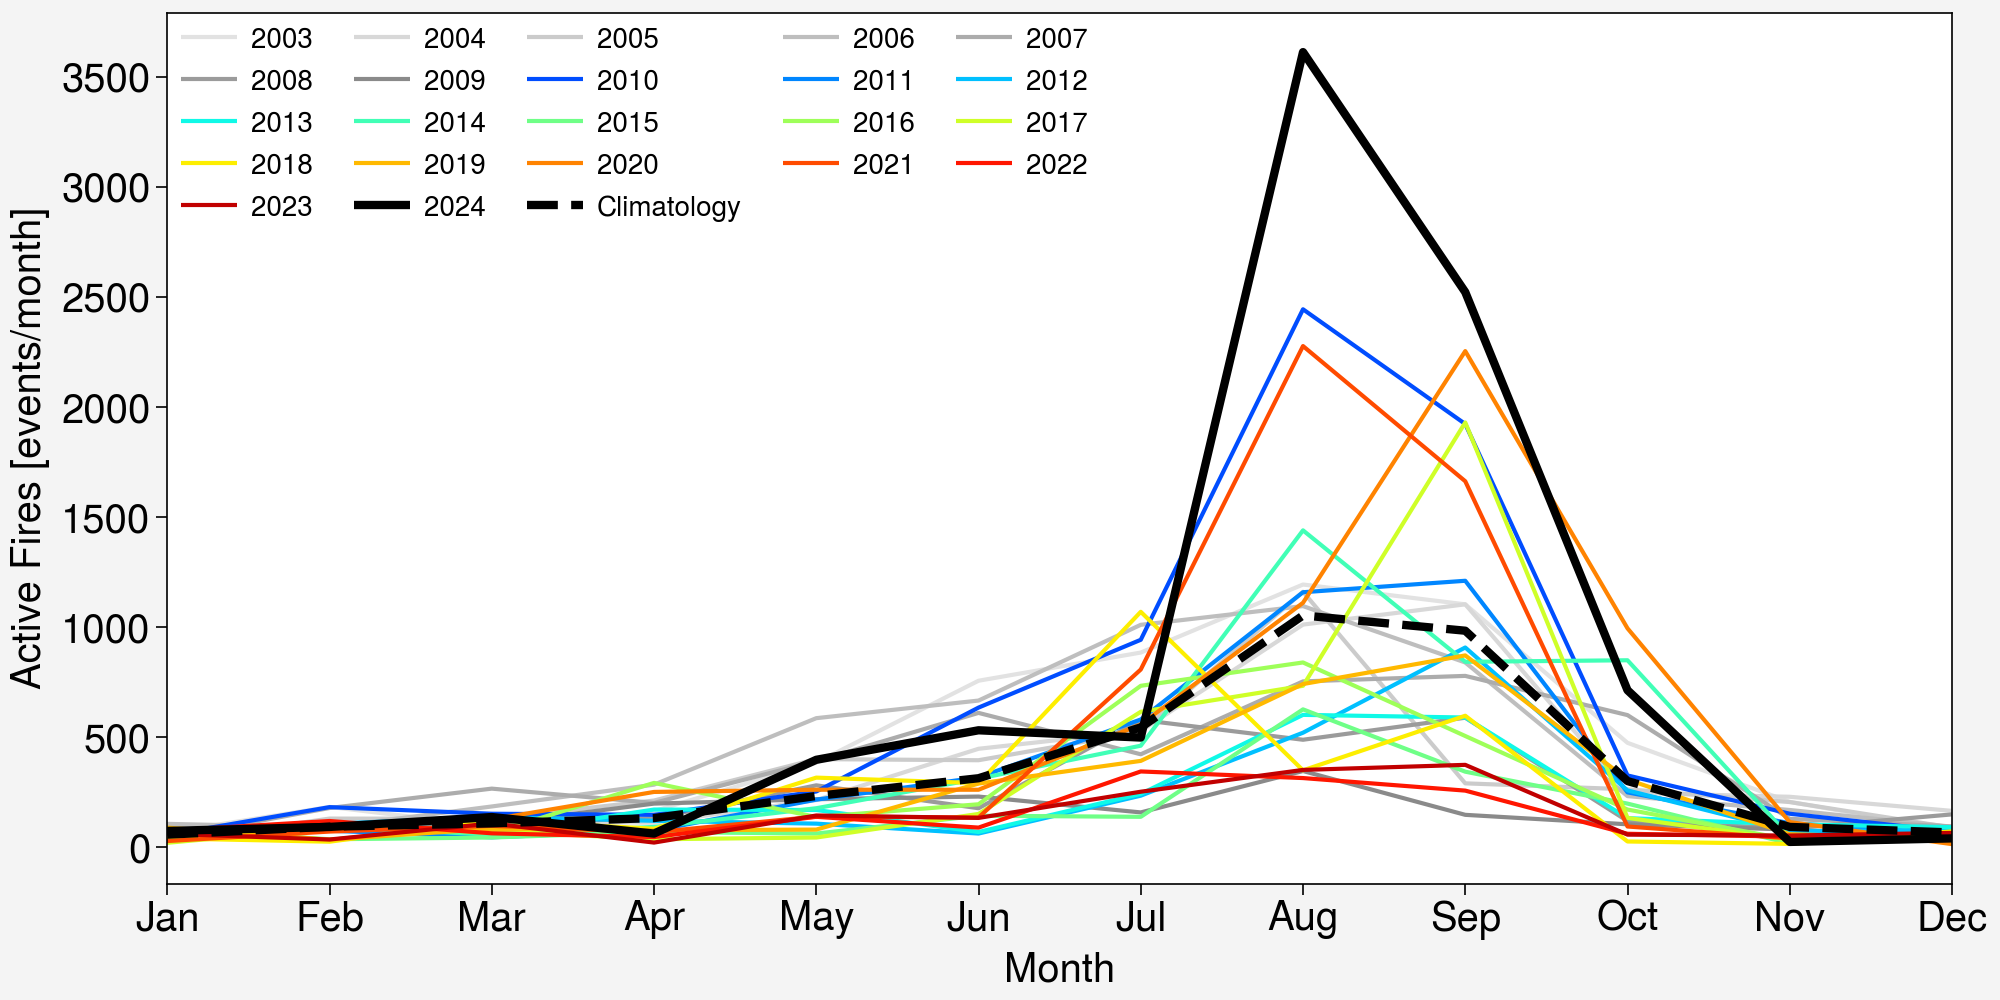

In [ ]:
#========================================================================================================================#
#                                          ACUMULA PARA MENSAL
#========================================================================================================================#
# seleciona os focos para um determinado Estado
df_total_filtrado = df_2003_a_2024[ df_2003_a_2024['estado'] == 'SÃO PAULO' ]

# calculando o mensal total
df_mensal_total = df_total_filtrado.groupby(pd.Grouper(freq='1M')).count()['lat']

# calculando o mensal climatologia
df_mensal_climatologia = df_mensal_total.groupby(df_mensal_total.index.month).mean()

#========================================================================================================================#
#                                                PLOTA FIGURA
#========================================================================================================================#
# moldura da figura
fig, ax = uplt.subplots(figsize=(10,5), tight=True)

# 2003-2009
anoi, anof = 2003, 2009
cycle = uplt.Cycle('Greys', left=0.2, N=15)
for ano in np.arange(anoi, anof+1):
    ax.plot(uplt.arange(1, 12, 1),
            df_mensal_total[str(ano)].values,
            label=str(ano),
            cycle=cycle)

# 2010-2023
anoi, anof = 2010, 2023
cycle = uplt.Cycle('jet', left=0.2, N=15)
for ano in np.arange(anoi, anof+1):
    ax.plot(uplt.arange(1, 12, 1),
            df_mensal_total[str(ano)].values,
            label=str(ano),
            cycle=cycle)

# 2024
val2024 = df_mensal_total['2024'].values
ax.plot(uplt.arange(1, 12, 1),
        val2024,
        label='2024',
        color='black',
        lw=3)

# mensal climatologia
ax.plot(uplt.arange(1, 12, 1),
        df_mensal_climatologia.values,
        label='Climatology',
        color='black',
        lw=3,
        ls='--')

# formato dos eixos
ax.format(ylabel='Active Fires [events/month]',
          small='20px',
          large='25px',
          xlabel='Month', xticks=1,
          xticklabels=['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
          xrotation=0, xtickminor=False, ytickminor=False, grid=False)

# legenda
ax.legend(loc='ul', ncols=5, frameon=False, prop={'size':10})

# salva figura
fig.save(f'{dir_output}/Fig_6_serie_temporal_mensal_SP.jpg', dpi=300)